# Academic Stress & Spotify - Progress Checkpoint

**Student:** Yazira Hernandez Rives  
**Email:** yazirarives@gmail.com  
**GitHub:** https://github.com/yazirahernandez/academic-stress-spotify

## Research Question
How do the average Spotify audio features (Energy and Valence) change between normal academic weeks and high-stress academic periods?

## Sources
1. students.csv (GitHub)
2. track_selections.csv (GitHub)
3. academic_calendar.csv (GitHub)

## Progress
- Connected to 3 GitHub data sources
- Cleaned data
- Merged datasets
- Calculated indicators
- Generated visualizations


In [1]:
# Logging setup (for professor review)
import logging

logging.basicConfig(
    filename='pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info('Notebook initialized')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

base='https://raw.githubusercontent.com/yazirahernandez/academic-stress-spotify/main/data/'
students=pd.read_csv(base+'students.csv')
tracks=pd.read_csv(base+'track_selections.csv')
calendar=pd.read_csv(base+'academic_calendar.csv')

print('Students'); display(students.head())
print('Tracks'); display(tracks.head())
print('Calendar'); display(calendar.head())

Students


,student_id,name,email,spotify_user_id
0,STU001,Student 1,student1@university.edu,spotify_user_1
1,STU002,Student 2,student2@university.edu,spotify_user_2
2,STU003,Student 3,student3@university.edu,spotify_user_3
3,STU004,Student 4,student4@university.edu,spotify_user_4
4,STU005,Student 5,student5@university.edu,spotify_user_5


Tracks


,student_id,week_number,week_type,spotify_track_id,track_name,artist_name,energy,valence
0,STU001,1,normal,track_nm_001,Blinding Lights,The Weeknd,0.73,0.64
1,STU001,2,normal,track_nm_002,Good as Hell,Lizzo,0.68,0.85
2,STU001,3,high-stress,track_hs_002,Pumped Up Kicks,Foster the People,0.75,0.49
3,STU001,4,normal,track_nm_002,Good as Hell,Lizzo,0.68,0.85
4,STU001,5,normal,track_nm_001,Blinding Lights,The Weeknd,0.73,0.64


Calendar


,week_number,start_date,end_date,week_type,project_deadline
0,1,2024-01-08,2024-01-15,normal,NaN
1,2,2024-01-15,2024-01-22,normal,NaN
2,3,2024-01-22,2024-01-29,high-stress,Project 2 Deadline
3,4,2024-01-29,2024-02-05,normal,NaN
4,5,2024-02-05,2024-02-12,normal,NaN


In [ ]:
df=tracks.merge(calendar,on='week_number',how='left')
df=df.merge(students,on='student_id',how='left')
print('Merged shape:',df.shape)
display(df.head())

print('Missing values')
display(df.isna().sum())

print('Duplicates:',df.duplicated().sum())
df=df.drop_duplicates()

Merged shape: (800, 15)


,student_id,week_number,week_type_x,spotify_track_id,track_name,artist_name,energy,valence,start_date,end_date,week_type_y,project_deadline,name,email,spotify_user_id
0,STU001,1,normal,track_nm_001,Blinding Lights,The Weeknd,0.73,0.64,2024-01-08,2024-01-15,normal,NaN,Student 1,student1@university.edu,spotify_user_1
1,STU001,2,normal,track_nm_002,Good as Hell,Lizzo,0.68,0.85,2024-01-15,2024-01-22,normal,NaN,Student 1,student1@university.edu,spotify_user_1
2,STU001,3,high-stress,track_hs_002,Pumped Up Kicks,Foster the People,0.75,0.49,2024-01-22,2024-01-29,high-stress,Project 2 Deadline,Student 1,student1@university.edu,spotify_user_1
3,STU001,4,normal,track_nm_002,Good as Hell,Lizzo,0.68,0.85,2024-01-29,2024-02-05,normal,NaN,Student 1,student1@university.edu,spotify_user_1
4,STU001,5,normal,track_nm_001,Blinding Lights,The Weeknd,0.73,0.64,2024-02-05,2024-02-12,normal,NaN,Student 1,student1@university.edu,spotify_user_1


Missing values


,0
student_id,0
week_number,0
week_type_x,0
spotify_track_id,0
track_name,0
artist_name,0
energy,0
valence,0
start_date,0
end_date,0


Duplicates: 0


In [ ]:
summary=df.groupby('week_type_x')[['energy','valence']].mean().round(3)
print('Indicators')
display(summary)

Indicators


,energy,valence
week_type_x,,
high-stress,0.857,0.500
normal,0.705,0.745


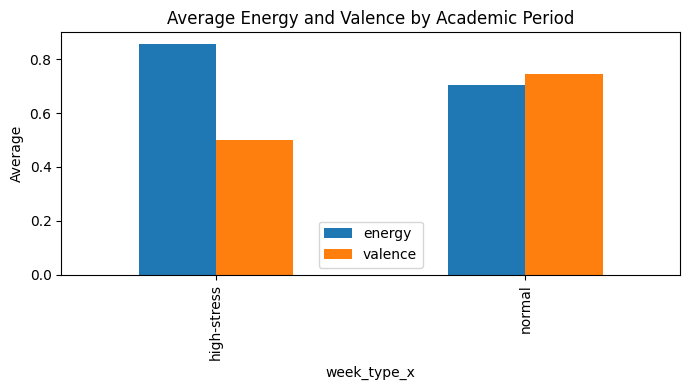

In [ ]:
summary.plot(kind='bar',figsize=(7,4))
plt.title('Average Energy and Valence by Academic Period')
plt.ylabel('Average')
plt.tight_layout()
plt.show()